# Física Computacional
**Sergio A. Alcalá Corona, Joel Gómez Uribe y Rodrigo Vega Vilchis**
**Grupo 8270 | Semestre 2027-1**

### Tarea-Práctica 3. Graficación en Python

**Alumno: Diego Alessandro Santiago Martínez**


**Fecha de entrega:** 7 de octubre de 2026

## 1. Gráfica de datos experimentales

El archivo `manchasolares.txt` (adjunto), contiene el número observado de manchas solares en el Sol en cada mes desde enero de 1749. El archivo contiene dos columnas de números, la primera es el mes y la segunda el número de manchas solares.

**(a)** Escribe un programa que lea los datos y haga una gráfica de las manchas solares en función del tiempo.

**(b)** Modifica tu programa para mostrar solo los primeros 1000 datos (experimentales) en la gráfica.

**(c)** Modifica nuevamente tu programa para calcular y graficar la media (promedio) móvil de los datos, definida por:

$$Y_{k}=\frac{1}{2r+1}\sum_{m=-r}^{r}y_{k+m}$$

donde $r=5$ (en este caso) y $y_{k}$ son los números de manchas solares.
El programa debe graficar tanto los datos originales como la media móvil en el mismo gráfico, sólo sobre los primeros 1000 datos.

**Inciso a)**

In [1]:
import numpy as np
buffermanchas = open("data/manchasolares.txt","r")
guardado = []
datos =[[],[]]
for i in buffermanchas.readlines():
    guardado.append(i)
    
for j in guardado:
    separaciondatos = j.split()   
    for k in range(0,2):
        if k == 0:
            datos[0].append(int(separaciondatos[0]))
        elif k == 1:
            datos[1].append(float(separaciondatos[1]))
ejex = np.array(datos[0]) #Este en realidad no lo voy a ocupar por ahora.
años = np.linspace(1749,2011,3143) #Voy a graficar de acuerdo a los años acumulados.
ejey = np.array(datos[1])

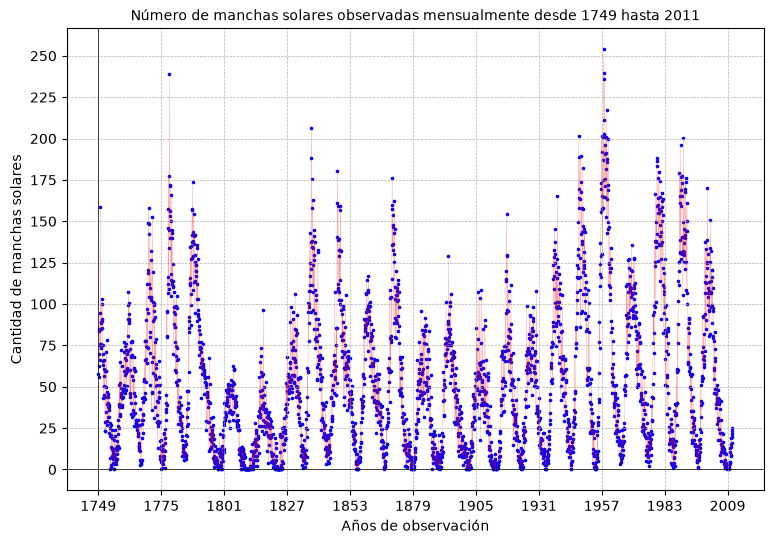

In [49]:
import matplotlib.pyplot as plt
from pylab import scatter,xlabel,ylabel,xlim,ylim,show

plt.figure(figsize=(9,6))

scatter(años,ejey,s=2.5, c="b")
plt.plot(años, ejey, color="red", linestyle = "-", linewidth=0.2,alpha=0.5)

plt.xticks(np.arange(1749, 2011, 26))
plt.yticks(np.arange(0, 260, 25))

plt.title("Número de manchas solares observadas mensualmente desde 1749 hasta 2011",fontsize=10)
plt.xlabel("Años de observación")
plt.ylabel("Cantidad de manchas solares")
plt.axhline(y = 0.0, xmin = 0, color = 'black', linewidth = 0.5)
plt.axvline(x = 1749.0, ymin = 0.0, color = 'black', linewidth = 0.5)
plt.grid(linestyle = "--", linewidth = 0.5)

**Inciso b)**

In [50]:
import numpy as np
buffermanchas = open("data/manchasolares.txt","r")
guardado = []
datos =[[],[]]
for i in buffermanchas.readlines():
    guardado.append(i)
    
for j in guardado:
    separaciondatos = j.split()   
    for k in range(0,2):
        if k == 0:
            datos[0].append(int(separaciondatos[0]))
        elif k == 1:
            datos[1].append(float(separaciondatos[1]))
ejex = np.array(datos[0]) 
ejey = np.array(datos[1])
primerosmilmeses = np.split(ejex[:1000],1) 
primerasmilobservaciones = np.split(ejey[:1000],1) 

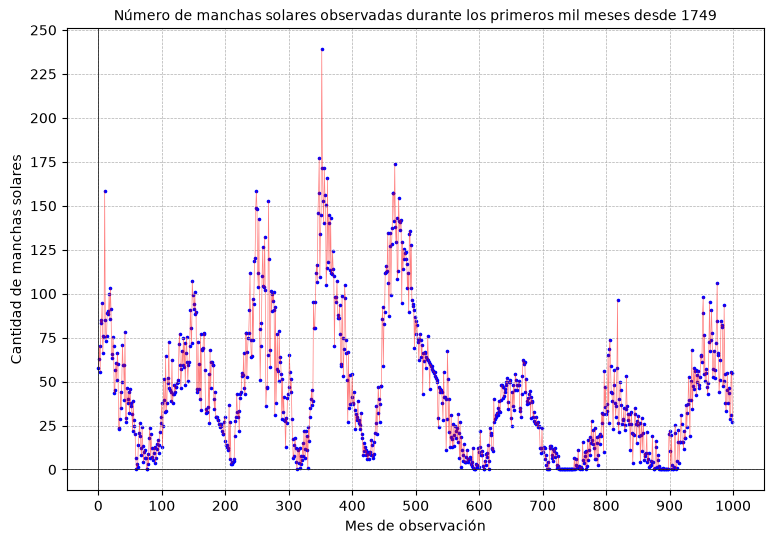

In [60]:
import matplotlib.pyplot as plt
from pylab import scatter,xlabel,ylabel,xlim,ylim,show

plt.figure(figsize=(9,6))

scatter(primerosmilmeses[0],primerasmilobservaciones[0],s=2.5, c="b")
plt.plot(primerosmilmeses[0], primerasmilobservaciones[0], color="red", linestyle = "-", linewidth=0.5,alpha=0.5)

plt.xticks(np.arange(0, 1001, 100))
plt.yticks(np.arange(0, 260, 25))

plt.title("Número de manchas solares observadas durante los primeros mil meses desde 1749",fontsize=10)
plt.xlabel("Mes de observación")
plt.ylabel("Cantidad de manchas solares")
plt.axhline(y = 0.0, xmin = 0, color = 'black', linewidth = 0.5)
plt.axvline(x = 0.0, ymin = 0.0, color = 'black', linewidth = 0.5)
plt.grid(linestyle = "--", linewidth = 0.5)

**Inciso c)**

In [61]:
Mediamovil = []
r = 5
for k in range(r, len(primerasmilobservaciones[0])-r):
    suma_k = 0
    for m in range(-r,r+1):
        suma_k += primerasmilobservaciones[0][k+m]
    Yk = 1/(2*r+1)*suma_k
    Mediamovil.append(Yk)

Y = np.array(Mediamovil)

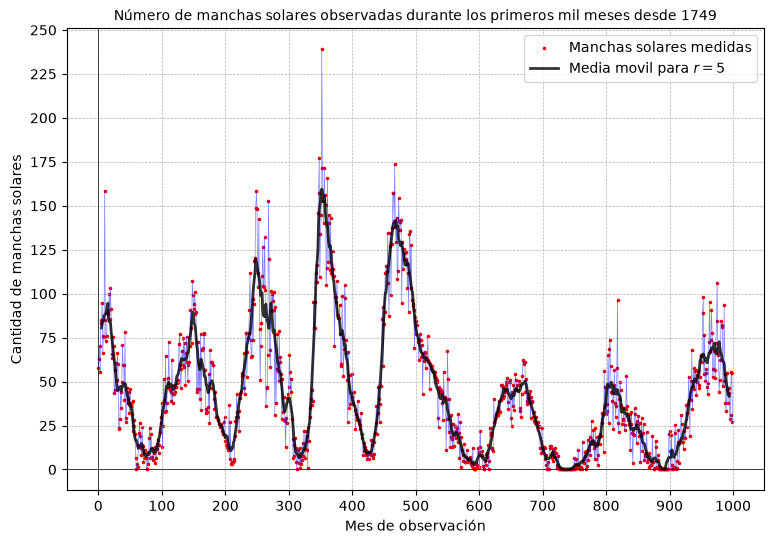

In [74]:
import matplotlib.pyplot as plt
from pylab import scatter,xlabel,ylabel,xlim,ylim,show

plt.figure(figsize=(9,6))

scatter(primerosmilmeses[0],primerasmilobservaciones[0],s=2.5, c="r",label = "Manchas solares medidas")
plt.plot(primerosmilmeses[0], primerasmilobservaciones[0], color="blue", linestyle = "-", linewidth=0.5,alpha=0.5)
plt.plot(range(r, len(primerasmilobservaciones[0])-r), Y, color="black", linestyle = "-", linewidth=2,alpha=0.8, label = "Media movil para $r=5$")

plt.xticks(np.arange(0, 1001, 100))
plt.yticks(np.arange(0, 260, 25))


plt.title("Número de manchas solares observadas durante los primeros mil meses desde 1749",fontsize=10)
plt.xlabel("Mes de observación")
plt.ylabel("Cantidad de manchas solares")
plt.axhline(y = 0.0, xmin = 0, color = 'black', linewidth = 0.5)
plt.axvline(x = 0.0, ymin = 0.0, color = 'black', linewidth = 0.5)
plt.legend()
plt.grid(linestyle = "--", linewidth = 0.5)

## 2. La gráfica de Feigenbaum (caos determinista)

En un especial de halloween de los Simpsons, Homero viaja al pasado a la era Jurásica y por un pequeño descuido cambia el curso de toda la historia en el futuro. Lo anterior es una referencia al cuento *A Sound of Thunder* de 1952 del escritor de ciencia ficción Ray Bradbury en donde lo que se destruye en el pasado es una mariposa. Esta idea fue retomada y popularizada por el físico Edward Lorenz en 1972 cuando dio una conferencia en la Asociación Estadounidense para el Avance de la Ciencia (American Association for the Advancement of Science) titulada "¿El aleteo de una mariposa en Brasil puede provocar un tornado en Texas?". Dando paso al concepto del efecto mariposa, del cual probablemente hayas oído hablar y que es el ejemplo clásico de caos determinista en sistemas climáticos. 

El caos determinista también aparece en muchos sistemas físicos más complejos, incluyendo especialmente la dinámica de fluidos. Debido a su naturaleza aparentemente aleatoria, el comportamiento de los sistemas caóticos es difícil de predecir y se ve fuertemente afectado por pequeñas perturbaciones en las condiciones iniciales. Uno de los ejemplos más famosos del fenómeno del caos determinista es sin duda el *mapeo logístico*, que es un sistema matemático muy simple, definido por la ecuación:

$$x_{n+1}=rx_{n}(1-x_{n})$$

Para un valor dado de la constante $r$, se toma un valor de $x_{n}$ (digamos $x=\frac{1}{2}$) y se introduce en el lado derecho de esta ecuación y regresa un valor de $x_{n+1}$. Luego se toma ese valor y se vuelve a introducir en el lado derecho, lo que da otro valor, y así sucesivamente. Esto es un mapeo iterativo. Se continua haciendo la misma operación una y otra vez sobre su valor de $x_{n}$, y entonces sucede una de las tres siguiente situaciones:

**(i)** El valor se establece en un número fijo y permanece allí. Esto se llama *punto fijo*. Por ejemplo, $x_{n}=0$ es siempre un punto fijo del mapeo logístico. (Si se pone $x_{n}=0$ en el lado derecho se obtiene $x_{n+1}=0$ en el lado izquierdo).

**(ii)** No se establece en un solo valor, sino que se establece en un patrón periódico, rotando alrededor de un conjunto de valores, digamos cuatro valores, repitiéndose en secuencia una y otra vez. Esto se llama *órbita* (en este caso de periodo 4) o *ciclo límite*.

**(iii)** Todo enloquece. El mapeo, genera una secuencia aparentemente aleatoria de números que parecen no tener ni patrón ni razón (ni ton ni son). Esto es el *caos determinista*. "Caos" porque realmente parece caótico y "determinista" porque aunque los valores parecen aleatorios, no lo son. Son a todas luces, totalmente predecibles, porque se obtienen mediante una simple ecuación y el comportamiento está determinado, aunque no lo parezca.

### Responde a las siguientes preguntas:

**(a)** Apóyate en el programa que vimos en clase y escribe un programa que muestre el comportamiento del mapeo logístico mediante una gráfica.

**(b)** De acuerdo a tu gráfica, ¿a qué valor de $r$ el sistema pasa de un comportamiento ordenado (puntos fijos o ciclos límite) a un comportamiento caótico? A este punto a veces se le llama "el borde del caos".

**Hint: Esto es lo que debes hacer para hacer tu programa:**
Para un valor dado de $r$, comienza con $x_{n}=\frac{1}{2}$ e itera la ecuación del mapeo logístico mil veces. Eso le dará la oportunidad de establecerse en un punto fijo o en una órbita de algún periodo. Luego ejecuta otras mil iteraciones y grafica los puntos $(r,x_{\infty})$ en una gráfica donde el eje horizontal es $r$ y el eje vertical es $x_{\infty}$.
Puedes usar la función `plot` con las opciones `"ko"` o `"k."` para dibujar una gráfica con puntos, uno para cada punto, o puedes usar la función `scatter` para dibujar un diagrama de dispersión (que siempre usa puntos). Repite todo el cálculo para valores de $r$ de 1 a 4 en pasos de 0.01, graficando los puntos para todos los valores de $r$ en la misma figura. Tu programa debería generar la distintiva gráfica que parece un árbol inclinado hacia un lado. Esta famosa imagen se llama *Gráfica de Feigenbaum*¹, en honor a su descubridor Mitchell Feigenbaum.

> ¹ A veces también se suele llamar gráfica de higuera, debido al juego de palabras que surge del hecho de que parece un árbol y Feigenbaum significa "higuera" en alemán.

**(c) \*\* Opcional (para 1.5 puntos extra):** Hay otra forma para calcular el diagrama de Feigenbaum, que puede ser más claro y rápido, dado que hace uso de la capacidad de Python para realizar aritmética con arreglos completos. Crear un arreglo $r$ que contenga cada valor distinto de $r$, `[1.0, 1.01, 1.02, ...]`. Crea otro arreglo $x$ del mismo tamaño para guardar los valores correspondientes de $x_{1}$ establecidos inicialmente en 0.5; finalmente realiza una iteración del mapeo logístico para todos los valores de $r$ a la vez, con una sola instrucción de la forma `x = r * x * (1 - x)` y compárala con tu programa anterior ².

> ² Debido a la velocidad con la que Python puede realizar cálculos con arreglos, este método debería ser significativamente más rápido que el método más básico anterior.

**Inciso a)**

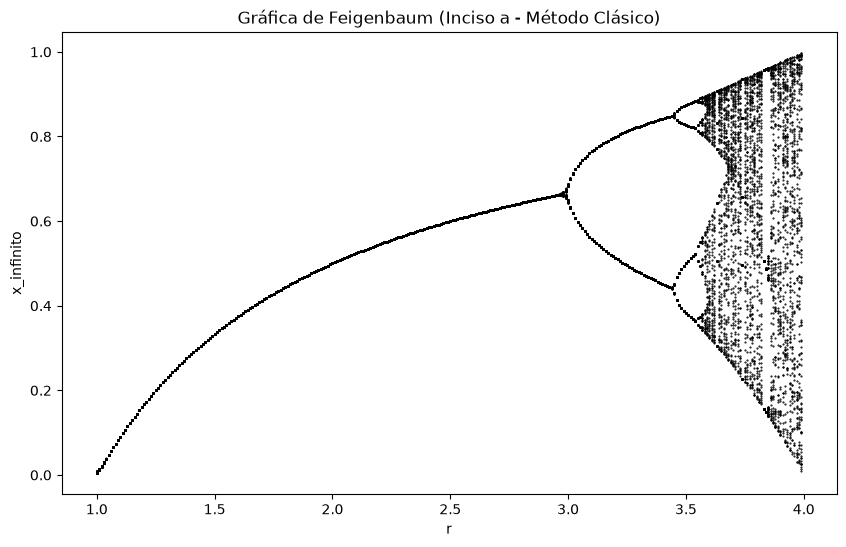

In [89]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Diferencia clave 1: Bucle principal iterando sobre cada valor de r individualmente
# Se calculan los valores de r de 1 a 4 en pasos de 0.01, tal como pide el texto.
for r in np.arange(1.0, 4.0, 0.01):
    
    # Condición inicial x_n = 1/2 para cada valor de r
    x = 0.5
    
    # Mil iteraciones iniciales para establecerse en un punto fijo o en una órbita
    for _ in range(100):
        x = r * x * (1 - x)
        
    # Otras mil iteraciones para graficar los puntos
    for _ in range(100):
        x = r * x * (1 - x)
        
        # Diferencia clave 2: Se llama a plot individualmente miles de veces.
        # Se usa 'k.' para graficar puntos negros como sugiere el documento.
        plt.plot(r, x, 'k.', markersize=1)

plt.title("Gráfica de Feigenbaum (Inciso a - Método Clásico)")
plt.xlabel("r")
plt.ylabel("x_infinito")
plt.show()

**Inciso b)**

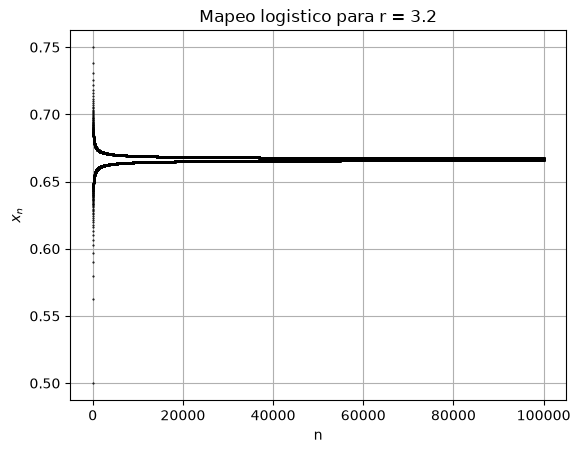

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Elegimos un solo valor de r
r = 2.999999999

# Numero de iteraciones
N = 100000

# Creamos el arreglo para guardar x
x = np.zeros(N)

# Condicion inicial
x[0] = 0.5

# Aplicamos el mapeo logistico
for n in range(N - 1):
    x[n + 1] = r * x[n] * (1 - x[n])

# Graficamos x_n contra n
plt.plot(range(N), x, 'k.', markersize=1)

plt.xlabel("n")
plt.ylabel("$x_n$")
plt.title("Mapeo logistico para r = 3.2")

plt.grid()

**Inciso c)**

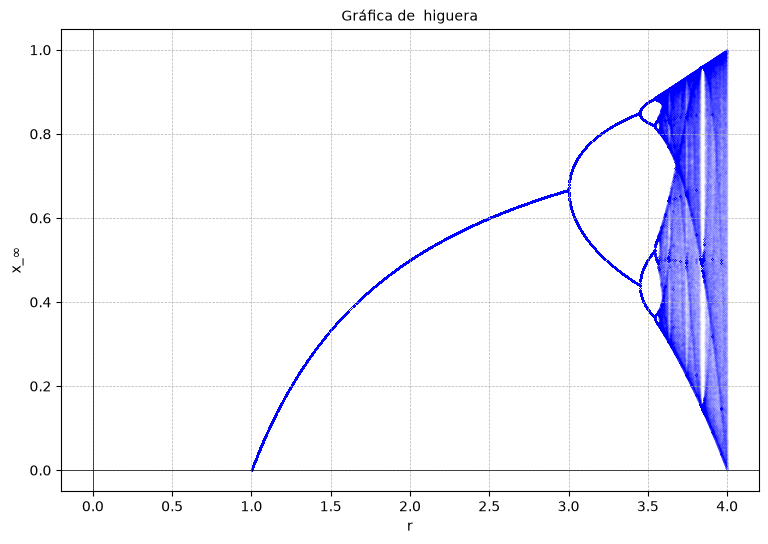

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from pylab import scatter,xlabel,ylabel,xlim,ylim,show


x1=0.5
p = []
for m in range (0, len(R)):
    p.append(x1)
    
R = np.arange(1,4,0.001)
X = np.array(p)

plt.figure(figsize=(9,6))


for i in range(0,1000):
    X = R*X*(1-X)
for j in range(0,1000):
    X = R*X*(1-X)    
    scatter(R,X, s = 0.005, c = "blue", alpha = 0.1)

plt.title("Gráfica de  higuera",fontsize=10)
plt.xlabel("r")
plt.ylabel("x_∞")
plt.axhline(y = 0.0, xmin = 0, color = 'black', linewidth = 0.5)
plt.axvline(x = 0.0, ymin = 0.0, color = 'black', linewidth = 0.5)
plt.grid(linestyle = "--", linewidth = 0.5)


## 3. El conjunto de Mandelbrot

El conjunto de Mandelbrot, llamado así por su descubridor, el matemático francés Benoît Mandelbrot, es un fractal; un objeto matemático infinitamente ramificado que contiene estructura dentro de estructura dentro de estructura, tan profundamente como queramos mirar. La definición del conjunto de Mandelbrot en términos de números complejos es la siguiente.

Consideremos la ecuación:

$$z_{n+1} = z_{n}^2+c, \quad z_{n},c\in\mathbb{C}$$

donde $z_{n}$ es un número complejo y $c$ es una constante compleja. De manera, muy similar al mapeo logístico, la definición del conjunto de Mandelbrot implica la iteración repetida de esta ecuación para cualquier valor dado de $c$. La ecuación convierte un número de entrada $z_{n}$ en un número de salida $z_{n+1}$; de tal manera que se toma un valor inicial de $z_{0}$ y se introduce en la ecuación para obtener un nuevo valor $z_{1}$, luego tomamos ese valor y lo volvemos a introducir para obtener $z_{2}$ y así sucesivamente.
Así, el conjunto de Mandelbrot es el conjunto de puntos del plano complejo que satisface la siguiente definición:

*Para un valor dado de $c$ y la condición inicial $z_{0}=0$; si al iterar repetidamente la ecuación, la magnitud del valor resultante es mayor a dos (i.e. $|z_{\infty}|>2$), entonces el punto del plano complejo para ese valor $c$ no está en el conjunto de Mandelbrot; de lo contrario, si está en el conjunto.*

Para utilizar esta definición, en principio, habría que iterar infinitas veces para demostrar que un punto está en el conjunto de Mandelbrot, ya que un punto está en el conjunto sólo si la iteración nunca pasa de $|z_{n}|=2$. Sin embargo, en la práctica, simplemente se realiza una gran cantidad de iteraciones (digamos 100) y si $|z_{n}|$ no ha excedido 2 en ese momento, entonces lo consideramos suficientemente bueno.

**(a)** Escribe un programa para crear una imagen del conjunto de Mandelbrot realizando la iteración para todos los valores de $c=x+iy$ en una cuadrícula de $N\times N$ que abarque la región donde $-2\le x\le 2$ y $-2\le y\le 2$. Haz una gráfica de densidad (density plot) en el que los puntos de la cuadrícula dentro del conjunto de Mandelbrot estén coloreados en negro y los de afuera estén coloreados en blanco.

*Sugerencia:* Probablemente te resulte útil comenzar con una cuadrícula muy simple, es decir, con un valor pequeño de $N$ (quizás $N=100$) para que tu programa se ejecute rápidamente mientras lo pruebas. Una vez que te asegures de que funciona correctamente, aumenta el valor de $N$ para producir una imagen final de alta calidad de la forma del conjunto.

**(b) \*\* Opcional (para 1.5 puntos extra):** Si te aburrió lo anterior (o te resultó demasiado fácil), puedes programar otra variante del mismo ejercicio que puede producir imágenes sorprendentes. En lugar de colorear los puntos solo en blanco o negro, colorea los puntos de acuerdo con el número de iteraciones de la ecuación antes de que $|z_{n}|$ sea mayor que 2 (o bien el número máximo de iteraciones si es que $|z_{n}|$ nunca llega a ser mayor que 2). Si usas alguno de los esquemas más coloridos que Python proporciona para las gráficas de densidad, como `"hot"` o `"jet"`, puedes crear algunas imágenes muy espectaculares. Otra variante interesante es colorear según el logaritmo del número de iteraciones, lo que ayuda a revelar parte de la estructura más fina fuera del conjunto.

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from pylab import scatter,xlabel,ylabel,xlim,ylim,show

plt.figure(figsize=(9,6))
n = 100
N = np.arange(0,n+1,1)
Z = np.ones(len(N))*0

x = np.linspace(-2,2,n)
y = np.linspace(-2,2,n)

c = np.arange(complex(x,y))


for i in range(0,n):
    Z = Z*Z + c

imshow(N,Z)




TypeError: only 0-dimensional arrays can be converted to Python scalars

<Figure size 900x600 with 0 Axes>